# An Analysis of Strokes Gained on the PGA Tour during the 2024 Season

In [406]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import datetime as dt
import matplotlib.dates as mdates
import matplotlib.transforms as mtransforms
from sklearn.linear_model import LinearRegression
mpl.rc('axes', linewidth=1)  
sg_total = pd.read_csv("./pga_tour_2024/pgatour_stats_02675(SG Total)_2024.csv")
results_2024 = pd.read_csv("2024_results.csv")

## How many winners posted positive strokes gained, what percentage do they make up?

### Data Analysis

In [407]:
sg_total.head()

,rank,player,avg,total_sg_t,total_sg_t2g,total_sg_p,measured_rounds,tournament
0,1,Maverick McNealy,3.516,10.548,6.859,3.689,3,The RSM Classic
1,2,J.T. Poston,3.183,9.548,8.505,1.043,3,The RSM Classic
2,3,Mackenzie Hughes,3.172,9.517,2.934,6.583,3,The RSM Classic
3,4,Joel Dahmen,2.506,7.517,8.674,-1.157,3,The RSM Classic
4,4,Ben Griffin,2.506,7.517,5.013,2.504,3,The RSM Classic


In [408]:
results_2024.head()

,Tournament,Course,Date,POS,PLAYER,TOTAL,THRU,ROUND,R1,R2,R3,STROKES,R4,PROJ.,STARTING
0,Grant Thornton Invitational,Tiburón Golf Club,DEC 13 - 15,1,Tavatanakit / Knapp,-27,F,-7,58,66,65,189,NaN,NaN,NaN
1,Grant Thornton Invitational,Tiburón Golf Club,DEC 13 - 15,2,Thitikul / Kim,-26,F,-8,62,64,64,190,NaN,NaN,NaN
2,Grant Thornton Invitational,Tiburón Golf Club,DEC 13 - 15,3,Kupcho / Bhatia,-25,F,-8,59,68,64,191,NaN,NaN,NaN
3,Grant Thornton Invitational,Tiburón Golf Club,DEC 13 - 15,4,Henderson / Conners,-24,F,-10,59,71,62,192,NaN,NaN,NaN
4,Grant Thornton Invitational,Tiburón Golf Club,DEC 13 - 15,5,Boutier / Pavon,-21,F,-7,63,67,65,195,NaN,NaN,NaN


- For this visualization I will be using the following columns:
    - sg_total
        - player - the players name
        - total_sg_t - the total strokes gained for the tournament
        - measured_rounds - the number of rounds for the tournament
    - results_2024
        - PLAYER - the players name
        - POS - the players final position

### Data Processing

In [409]:
# group the dataframe by player and sum the total_sg_t 
sg_total_grouped = sg_total.groupby("player").sum(numeric_only=True)
# reset the index to have player as a column
sg_total_grouped = sg_total_grouped.reset_index()

# create a new column for sg total average across all tournaments
sg_total_grouped['sg_total_avg_all_tournaments'] = sg_total_grouped["total_sg_t"] / sg_total_grouped["measured_rounds"]
# only keep the player and sg_total_avg_all_tournaments columns
sg_total_grouped = sg_total_grouped[["player", "sg_total_avg_all_tournaments"]]

# sort the dataframe by total_sg in descending order    
sg_total_grouped = sg_total_grouped.sort_values(by="sg_total_avg_all_tournaments", ascending=False)
# keep player and pos columns
results_2024 = results_2024[["PLAYER", "POS"]]

# filter the dataframe for position 1
results_2024 = results_2024[results_2024["POS"] == "1"]
# group the dataframe by player and count the number of wins
results_2024_grouped = results_2024.groupby("PLAYER").count()

# reset the index to have player as a column
results_2024_grouped = results_2024_grouped.reset_index()
# keep only the player and POS columns
results_2024_grouped = results_2024_grouped[["PLAYER", "POS"]]

# rename the POS column to wins
results_2024_grouped = results_2024_grouped.rename(columns={"POS": "wins"})
# sort the dataframe by wins in descending order
results_2024_grouped = results_2024_grouped.sort_values(by="wins", ascending=False)

# merge the two dataframes on player
sg_total_grouped = sg_total_grouped.merge(results_2024_grouped, left_on="player", right_on="PLAYER", how="left")
# drop the PLAYER column
sg_total_grouped = sg_total_grouped.drop(columns=["PLAYER"])

# fill the NaN values in wins with 0
sg_total_grouped["wins"] = sg_total_grouped["wins"].fillna(0)
# convert the wins column to int
sg_total_grouped["wins"] = sg_total_grouped["wins"].astype(int)

### Intial Analysis

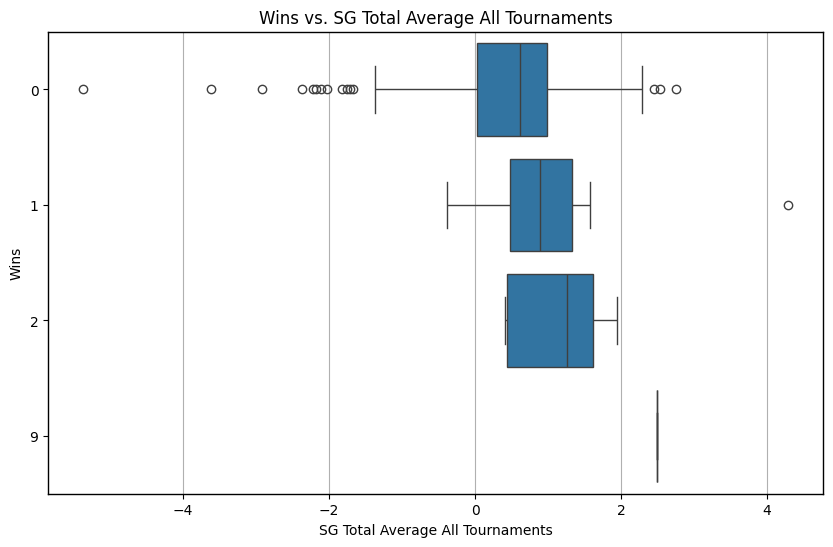

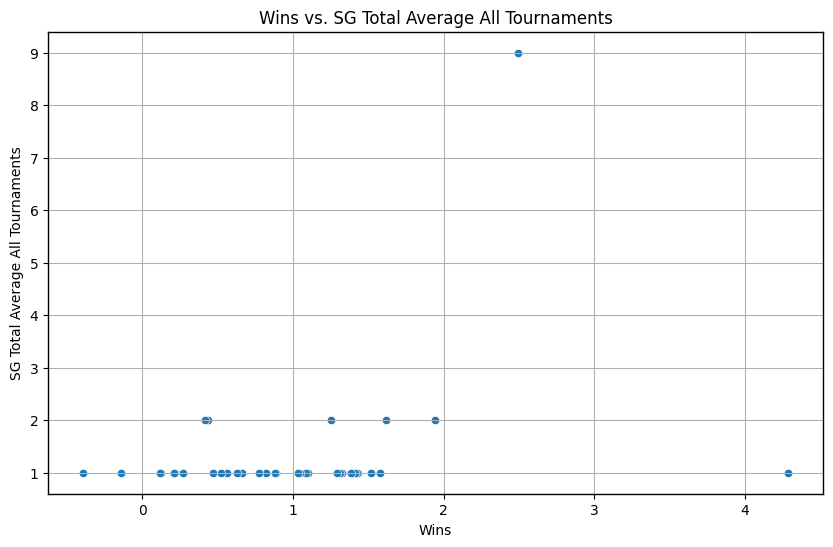

In [410]:
# create boxplot of sg_total_grouped 
plt.figure(figsize=(10, 6))
sns.boxplot(x="sg_total_avg_all_tournaments", y="wins", data=sg_total_grouped, orient="h")
plt.title("Wins vs. SG Total Average All Tournaments")
plt.xlabel("SG Total Average All Tournaments")
plt.ylabel("Wins")
plt.grid(axis='x')
plt.show()

# remove all 0 wins 
sg_total_grouped_winners = sg_total_grouped[sg_total_grouped["wins"] > 0]
# create a scatter plot of sg_total_grouped
plt.figure(figsize=(10, 6))
sns.scatterplot(x="sg_total_avg_all_tournaments", y="wins", data=sg_total_grouped_winners)
plt.title("Wins vs. SG Total Average All Tournaments")
plt.xlabel("Wins")
plt.ylabel("SG Total Average All Tournaments")
plt.grid()
plt.show()

### First Attempt

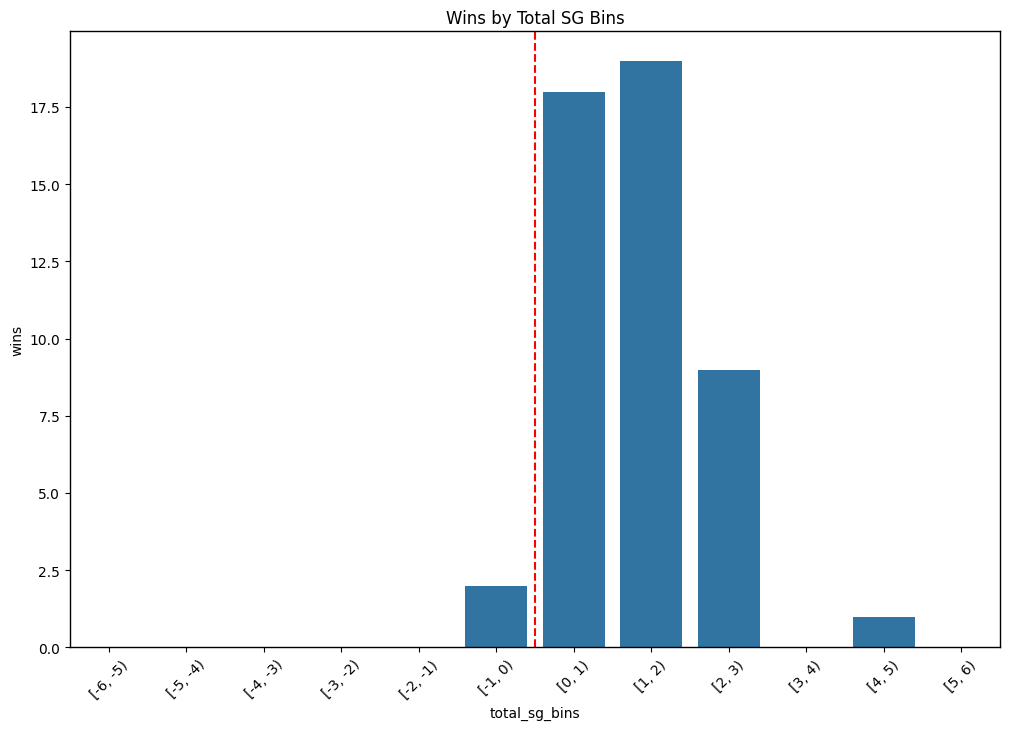

In [ ]:
# get the min and max of sg_total_avg_all_tournaments
max = sg_total_grouped["sg_total_avg_all_tournaments"].max().astype(np.int64)+1
min = sg_total_grouped["sg_total_avg_all_tournaments"].min().astype(np.int64)-1

# create bins for the sg_total_avg_all_tournaments
bins = np.arange(np.floor(min), np.ceil(max) + 2, 1) 
bins = pd.cut(sg_total_grouped["sg_total_avg_all_tournaments"], bins=bins, right=False)

# create a new column for the bins
sg_total_grouped["total_sg_bins"] = bins
# group the dataframe by total_sg_bins
sg_total_grouped_bins = sg_total_grouped.groupby("total_sg_bins", observed=False).sum(numeric_only=True)

# reset the index to have total_sg_bins as a column
sg_total_grouped_bins = sg_total_grouped_bins.reset_index()
# keep only the total_sg_bins and wins columns
sg_total_grouped_bins = sg_total_grouped_bins[["total_sg_bins", "wins"]]

# create a bar plot of the wins by total_sg_bins
plt.figure(figsize=(12, 8))
sns.barplot(x="total_sg_bins", y="wins", data=sg_total_grouped_bins)
# set x ticks and title
plt.xticks(rotation=45)
plt.title("Wins by Total SG Bins")
# put a vertical line at 0
plt.axvline(x=5.5, color='red', linestyle='--')

### Final Attempt

Text(2.2, 0.4, 'Percentage of wins \nwith positive SG:\n96%')

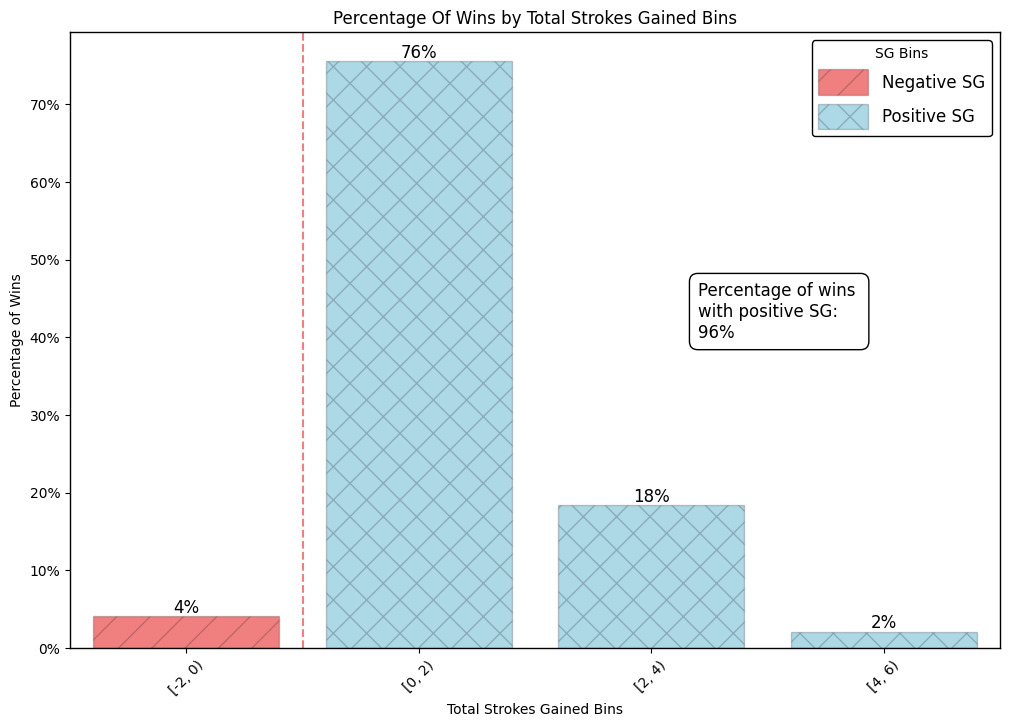

In [ ]:
# setting the bins for the histogram
bins = np.arange(-2, 7, 2) 
# create bins for the total_sg_avg_all_tournaments column
bins = pd.cut(sg_total_grouped["sg_total_avg_all_tournaments"], bins=bins, right=False)

# create a new column for the bins
sg_total_grouped["total_sg_bins"] = bins
# group the dataframe by total_sg_bins
sg_total_grouped_bins = sg_total_grouped.groupby("total_sg_bins", observed=False).sum(numeric_only=True)

# reset the index to have total_sg_bins as a column
sg_total_grouped_bins = sg_total_grouped_bins.reset_index()
# keep only the total_sg_bins and wins columns
sg_total_grouped_bins = sg_total_grouped_bins[["total_sg_bins", "wins"]]

# add percentage of wins with positive SG as a column
sg_total_grouped_bins["pct_of_positive_sg"] = sg_total_grouped_bins["wins"] / sg_total_grouped_bins["wins"].sum()

# create a bar plot of the wins by total_sg_bins
plt.figure(figsize=(12, 8))
sns.barplot(x="total_sg_bins", y="pct_of_positive_sg", data=sg_total_grouped_bins)
# format y-axis as percentage
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
# set x ticks, title, and labels
plt.xticks(rotation=45)
plt.xlabel("Total Strokes Gained Bins")
plt.ylabel("Percentage of Wins")
plt.title("Percentage Of Wins by Total Strokes Gained Bins")

# change positive bars to different colors
for i, bar in enumerate(plt.gca().patches):
    if sg_total_grouped_bins["total_sg_bins"].iloc[i].left >= 0:
        bar.set_color('lightblue')
        bar.set_hatch('x')
        bar.set_edgecolor((0, 0, 0, 0.2))
        bar.set_linewidth(1.0) 
    else:
        bar.set_color('lightcoral')
        bar.set_hatch('/')
        bar.set_edgecolor((0, 0, 0, 0.2))
        bar.set_linewidth(1.0) 

# add value labels on top of the bars
for bar in plt.gca().patches:
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0%}', ha='center', va='bottom', fontsize=12)

# add a legend  
handles = [
    plt.Rectangle((0,0), 1, 1, facecolor='lightcoral', edgecolor=(0, 0, 0, 0.2), hatch='/'),
    plt.Rectangle((0,0), 1, 1, facecolor='lightblue', edgecolor=(0, 0, 0, 0.2), hatch='x')
]
plt.legend(
    handles=handles,
    labels=['Negative SG','Positive SG'],
    title='SG Bins',
    handlelength=3,
    handleheight=2,
    loc='upper right',
    fontsize=12,
    facecolor='white',
    framealpha=1.0,
    edgecolor='black'
)

# put a vertical line at 0
plt.axvline(x=0.5, color='lightcoral', linestyle='--')

# add text box to show the percentage of wins with positive SG
pct_of_positive_sg = sg_total_grouped_bins[sg_total_grouped_bins["total_sg_bins"].apply(lambda x: x.left >= 0)]['wins'].sum() / sg_total_grouped_bins['wins'].sum()
plt.text(2.2, .40, f"Percentage of wins \nwith positive SG:\n{pct_of_positive_sg:.0%}", fontsize=12, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

## What is the relationship between a player’s average driving distance and their average strokes gained?

### Data Analysis

In [413]:
# loading the data
driving_distance = pd.read_csv("./pga_tour_2024/pgatour_stats_101(Driving Distance)_2024.csv")
sg_total = pd.read_csv("./pga_tour_2024/pgatour_stats_02675(SG Total)_2024.csv")

In [414]:
driving_distance.head()

,rank,player,avg,total_distance,total_drives,tournament
0,1.0,Christo Lamprecht,314.1,2513.0,8.0,The RSM Classic
1,2.0,Adrien Dumont de Chassart,310.5,2484.0,8.0,The RSM Classic
2,3.0,Luke Clanton,306.5,2452.0,8.0,The RSM Classic
3,4.0,Joseph Bramlett,305.5,2444.0,8.0,The RSM Classic
4,5.0,Ludvig Åberg,304.3,2434.0,8.0,The RSM Classic


In [415]:
sg_total.head()

,rank,player,avg,total_sg_t,total_sg_t2g,total_sg_p,measured_rounds,tournament
0,1,Maverick McNealy,3.516,10.548,6.859,3.689,3,The RSM Classic
1,2,J.T. Poston,3.183,9.548,8.505,1.043,3,The RSM Classic
2,3,Mackenzie Hughes,3.172,9.517,2.934,6.583,3,The RSM Classic
3,4,Joel Dahmen,2.506,7.517,8.674,-1.157,3,The RSM Classic
4,4,Ben Griffin,2.506,7.517,5.013,2.504,3,The RSM Classic


- For this visualization I will be using the following columns:
    - driving distance
        - player - the players name
        - tournament - the tournament name
        - total_distance - the total sum driving distance for the player
        - total_drives - the total count of drives for the player
        - measured_rounds - the number of rounds for the tournament
    - sg_total
        - total_sg_t - the total strokes gained for the tournament

### Data Processing

In [416]:
# driving_distance merge with sg_total join on player and tournament
driving_distance = driving_distance.merge(sg_total, on=["player", "tournament"], how="left")
# select only the relevant columns
driving_distance = driving_distance[["player", "tournament", "total_distance", "total_drives", "total_sg_t", "measured_rounds"]]

# group the dataframe by player and sum
driving_distance_grouped = driving_distance.groupby("player").sum(numeric_only=True).reset_index()
# calculate the average driving distance
driving_distance_grouped["avg_driving_distance"] = driving_distance_grouped["total_distance"] / driving_distance_grouped["total_drives"]

# calculate the average strokes gained total
driving_distance_grouped["avg_sg_t"] = driving_distance_grouped["total_sg_t"] / driving_distance_grouped["measured_rounds"]
# drop rows with NaN values in avg_driving_distance or avg_sg_t
driving_distance_grouped = driving_distance_grouped.dropna(subset=["avg_driving_distance", "avg_sg_t"])

# select only the relevant columns
driving_distance_grouped = driving_distance_grouped[["player", "avg_driving_distance", "avg_sg_t"]]
# calculate the mean of avg_driving_distance
driving_distance_grouped["avg_driving_distance"].mean()

# long driver if above the mean make driver classification
mean_driving_distance = driving_distance_grouped["avg_driving_distance"].mean()
driving_distance_grouped["driver_classification"] = np.where(driving_distance_grouped["avg_driving_distance"] > mean_driving_distance, "Longer Driver", "Shorter Driver")

### Intial Analysis

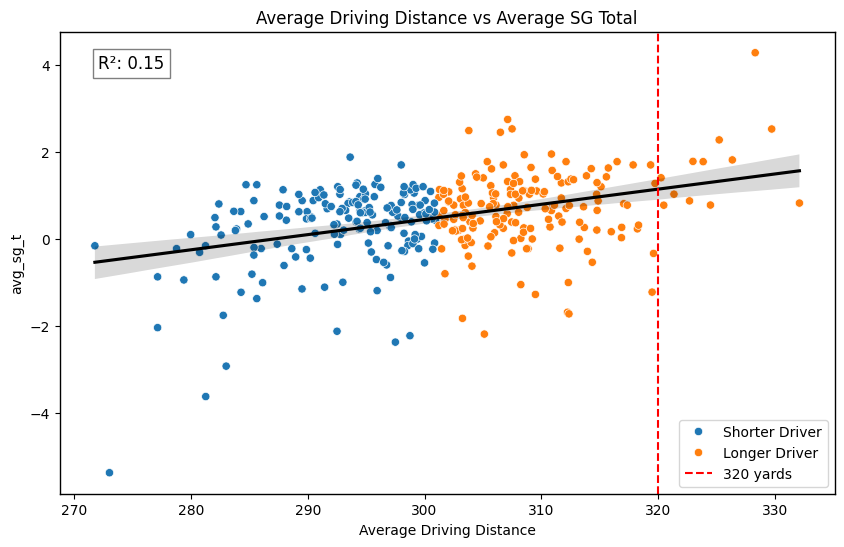

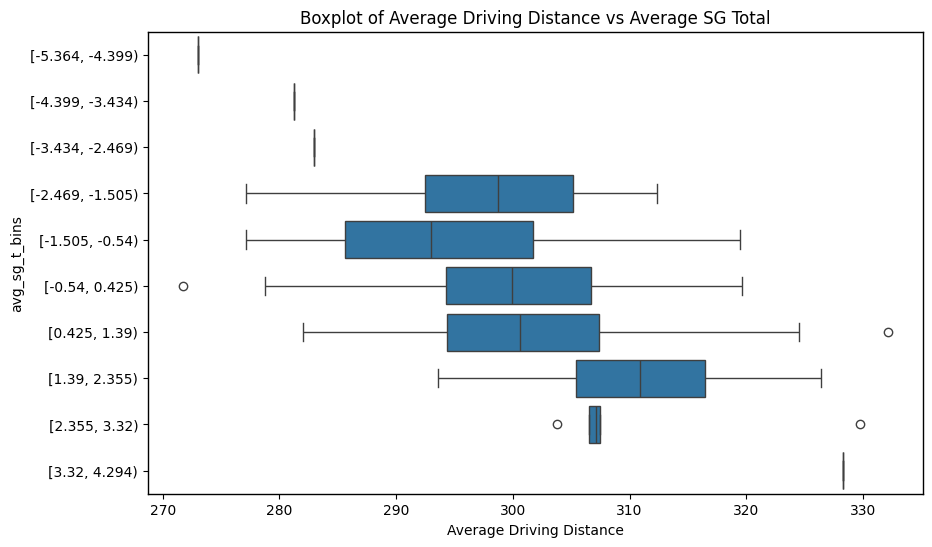

In [ ]:
#create a scatter plot of avg_driving_distance vs avg_sg_t
plt.figure(figsize=(10, 6))
sns.scatterplot(x="avg_driving_distance", y="avg_sg_t", hue="driver_classification", data=driving_distance_grouped)
plt.title("Average Driving Distance vs Average SG Total")

# add a regression line with r2 value   
sns.regplot(x="avg_driving_distance", y="avg_sg_t", data=driving_distance_grouped, scatter=False, color='black', line_kws={"label": "Regression Line"})

# get the x and y and fit the model
X = driving_distance_grouped[["avg_driving_distance"]]
y = driving_distance_grouped["avg_sg_t"]
model = LinearRegression()
model.fit(X, y)

# calculate r2 value
r2 = model.score(X, y)

# add a text box with the r2 value
plt.text(0.05, 0.95, f"R²: {r2:.2f}", transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
plt.xlabel("Average Driving Distance")

# draw a vertical line at 320
plt.axvline(x=320, color='red', linestyle='--', label='320 yards')
# add the legend
plt.legend()

# generate a boxplot of avg_driving_distance vs avg_sg_t
# bin the avg_sg_t into 10 bins
driving_distance_grouped["avg_sg_t_bins"] = pd.cut(driving_distance_grouped["avg_sg_t"], bins=10, right=False)
plt.figure(figsize=(10, 6))
sns.boxplot(x="avg_driving_distance", y="avg_sg_t_bins", data=driving_distance_grouped, orient="h")
plt.title("Boxplot of Average Driving Distance vs Average SG Total")
plt.xlabel("Average Driving Distance")
plt.show()

### Final Attempt

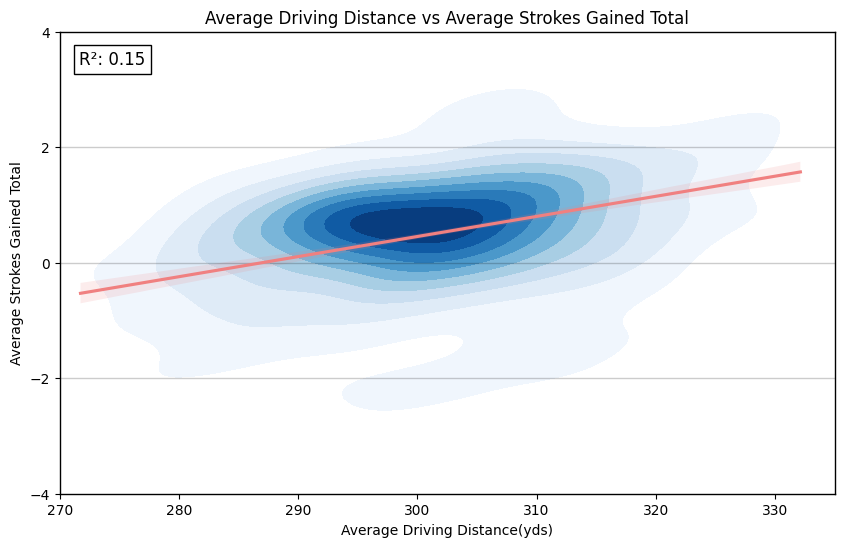

In [418]:
# generate a 2d density plot of avg_driving_distance vs avg_sg_t
plt.figure(figsize=(10, 6))
sns.kdeplot(x="avg_driving_distance", y="avg_sg_t", data=driving_distance_grouped, cmap="Blues", fill=True, thresh=0.05, levels=10)

# set y limits and only show even numbers
plt.ylim(-4, 4)
plt.yticks(np.arange(-4, 5, 2))

# set x limits and only show even numbers
plt.xlim(275, 335)
plt.xticks(np.arange(270, 331, 10))

# horizontal line at 0, 2, -2
plt.axhline(y=0, color=(0, 0, 0, 0.2), linestyle='-', linewidth=1.0)
plt.axhline(y=2, color=(0, 0, 0, 0.2), linestyle='-', linewidth=1.0)
plt.axhline(y=-2, color=(0, 0, 0, 0.2), linestyle='-', linewidth=1.0)

# add a regression line with r2 value   
sns.regplot(x="avg_driving_distance", y="avg_sg_t", data=driving_distance_grouped, scatter=False, color="lightcoral", line_kws={"label": "Regression Line"}, ci=65)
# set regplot line color to light gray
plt.gca().get_lines()[-1].set_color("lightcoral")

# fit the model and calculate r2 value
X = driving_distance_grouped[["avg_driving_distance"]]
y = driving_distance_grouped["avg_sg_t"]
model = LinearRegression()
model.fit(X, y)
r2 = model.score(X, y)

# add a text box with the r2 value
plt.text(0.025, 0.93, f"R²: {r2:.2f}", transform=plt.gca().transAxes, fontsize=12, bbox=dict(facecolor='white', edgecolor='black'))
plt.title("Average Driving Distance vs Average Strokes Gained Total")
plt.xlabel("Average Driving Distance(yds)")
plt.ylabel("Average Strokes Gained Total")
plt.show()

## Do those shorter hitters gain in any other strokes gained metrics?

### Data Analysis

In [419]:
sg_putting = pd.read_csv("./pga_tour_2024/pgatour_stats_02564(SG Putting)_2024.csv").drop(columns=["rank", "measured_rounds", "avg"])
sg_ttg = pd.read_csv("./pga_tour_2024/pgatour_stats_02674(SG From Tee To Green)_2024.csv").drop(columns=["rank"])
driving_distance = pd.read_csv("./pga_tour_2024/pgatour_stats_101(Driving Distance)_2024.csv")

In [420]:
sg_putting.head()

,player,total_sg_putting,tournament
0,Mackenzie Hughes,6.583,The RSM Classic
1,Nico Echavarria,5.575,The RSM Classic
2,Martin Trainer,5.333,The RSM Classic
3,Eric Cole,4.608,The RSM Classic
4,Kelly Kraft,4.425,The RSM Classic


In [421]:
sg_ttg.head()

,player,total,total_sg_ott_avg,total_sg_apr_avg,total_sg_arg_avg,measured_rounds,tournament
0,Joel Dahmen,2.891,1.120,0.924,0.847,3,The RSM Classic
1,J.T. Poston,2.835,0.480,2.275,0.080,3,The RSM Classic
2,Henrik Norlander,2.579,0.568,1.762,0.249,3,The RSM Classic
3,Maverick McNealy,2.286,0.782,1.258,0.247,3,The RSM Classic
4,Bud Cauley,1.931,0.669,0.487,0.775,3,The RSM Classic


In [422]:
driving_distance.head()

,rank,player,avg,total_distance,total_drives,tournament
0,1.0,Christo Lamprecht,314.1,2513.0,8.0,The RSM Classic
1,2.0,Adrien Dumont de Chassart,310.5,2484.0,8.0,The RSM Classic
2,3.0,Luke Clanton,306.5,2452.0,8.0,The RSM Classic
3,4.0,Joseph Bramlett,305.5,2444.0,8.0,The RSM Classic
4,5.0,Ludvig Åberg,304.3,2434.0,8.0,The RSM Classic


- For this visualization I will be using the following columns:
    - sg_putting
        - total_sg_putting - the total strokes gained in putting for the tournament
        - measured_rounds - the number of rounds for the tournament
    - sg_ttg
        - player - the players name
        - tournament - the tournament name
        - total_sg_ott_avg - the total strokes gained from off the tee for the tournament
        - total_sg_apr_avg - the total strokes gained from approach for the tournament
        - total_sg_arg_avg - the total strokes gained from around the green for the tournament
        - measured_rounds - the number of rounds for the tournament
    - driving_distance
        - total_distance - the total sum driving distance for the player
        - total_drives - the total count of drives for the player

### Data Processing

In [423]:
# remove unnecessary columns from sg_ttg
sg_ttg = sg_ttg[["player", "tournament", "total_sg_ott_avg", "total_sg_apr_avg", "total_sg_arg_avg", "measured_rounds"]]

# merge sg_putting and sg_ttg on player and tournament
combined_sg = pd.merge(sg_putting, sg_ttg, on=["player", "tournament"], how="outer")
# calculate the average strokes gained putting
combined_sg["total_sg_putting_avg"] = combined_sg["total_sg_putting"] / combined_sg["measured_rounds"]
# drop the total_sg_putting and measured_rounds columns
combined_sg = combined_sg.drop(columns=["total_sg_putting", "measured_rounds"])

# merge combined_sg with driving_distance on player and tournament
combined_sg = pd.merge(combined_sg, driving_distance, on=["player", "tournament"], how="left")
# group combined_sg by player and sum 
combined_sg = combined_sg.groupby("player").sum(numeric_only=True).reset_index()
# calculate the average driving distance
combined_sg["avg_driving_distance"] = combined_sg["total_distance"] / combined_sg["total_drives"]
# drop the total_distance, total_drives, rank, and avg columns
combined_sg = combined_sg.drop(columns=["total_drives", "total_distance", "rank", "avg"])
# calculate the average driving distance
mean_driving_distance = driving_distance_grouped["avg_driving_distance"].mean()
combined_sg_long = combined_sg[combined_sg["avg_driving_distance"] >= mean_driving_distance]
combined_sg_short = combined_sg[combined_sg["avg_driving_distance"] < mean_driving_distance]

### First Attempt

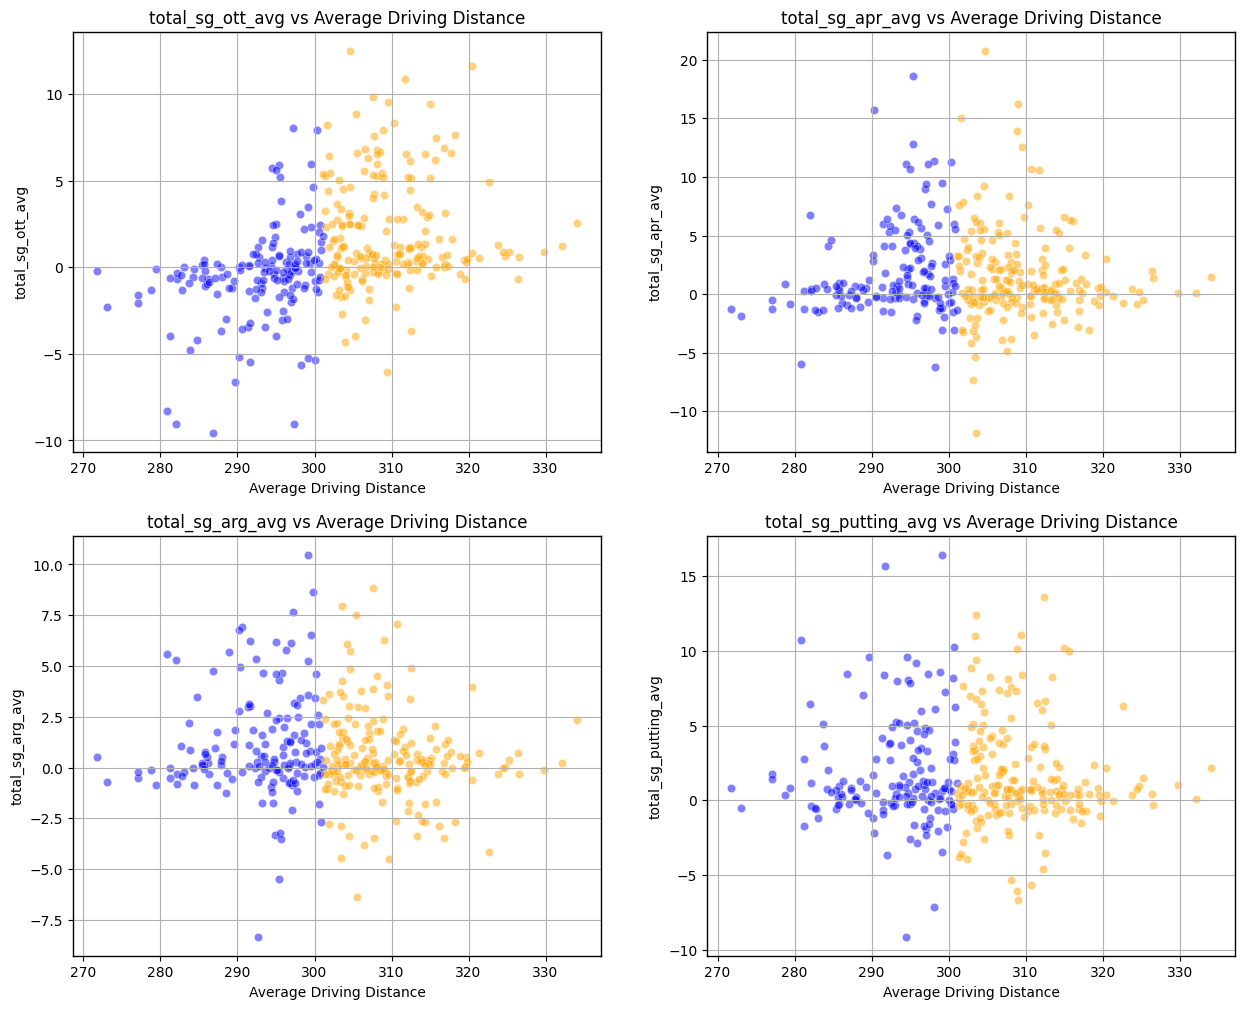

In [424]:
# create a small multiple scatter plot for each total_sg column against avg_driving_distance
plt.figure(figsize=(15, 12))
# iterate over the columns in combined_sg
for col in combined_sg.columns:
    # check if the column name contains "total_sg"
    if "total_sg" in col:
        # create a subplot for each column
        plt.subplot(2, 2, list(combined_sg.columns).index(col))
        sns.scatterplot(x="avg_driving_distance", y=col, data=combined_sg_short, color='blue', alpha=0.5)
        sns.scatterplot(x="avg_driving_distance", y=col, data=combined_sg_long, color='orange', alpha=0.5)
        plt.title(f"{col} vs Average Driving Distance")
        plt.xlabel("Average Driving Distance")
        plt.ylabel(col)
        plt.grid()

### Final Attempt

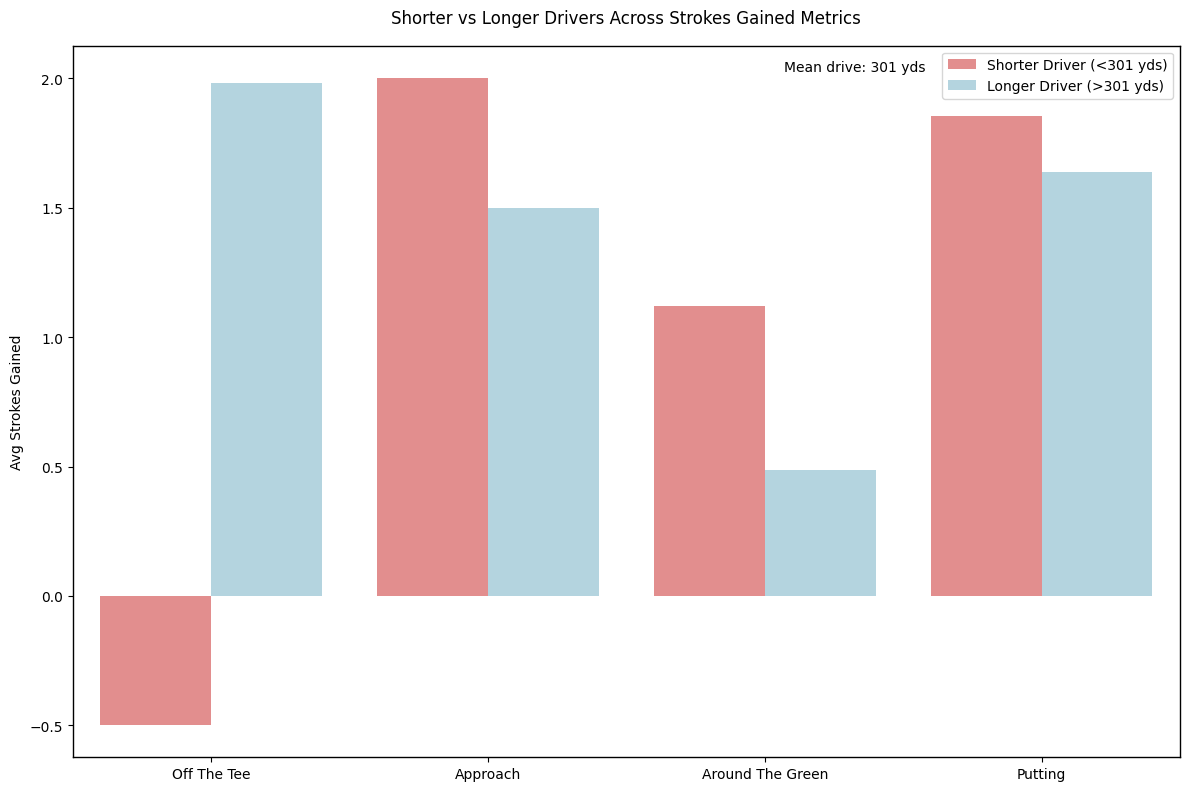

In [425]:
# create new df to hold the average of each total_sg column for long and short drivers
data = pd.DataFrame({
    "driver_classification": [
        "Shorter Driver (<301 yds)", "Longer Driver (>301 yds)",
        "Shorter Driver (<301 yds)", "Longer Driver (>301 yds)",
        "Shorter Driver (<301 yds)", "Longer Driver (>301 yds)",
        "Shorter Driver (<301 yds)", "Longer Driver (>301 yds)",
    ],
    "metric": [
        "total_sg_ott_avg", "total_sg_ott_avg", 
        "total_sg_apr_avg", "total_sg_apr_avg",
        "total_sg_arg_avg", "total_sg_arg_avg",
        "total_sg_putting_avg", "total_sg_putting_avg"
    ],
    "avg_sg": [
        combined_sg_short["total_sg_ott_avg"].mean().round(4), combined_sg_long["total_sg_ott_avg"].mean().round(4), 
        combined_sg_short["total_sg_apr_avg"].mean().round(4), combined_sg_long["total_sg_apr_avg"].mean().round(4), 
        combined_sg_short["total_sg_arg_avg"].mean().round(4), combined_sg_long["total_sg_arg_avg"].mean().round(4), 
        combined_sg_short["total_sg_putting_avg"].mean().round(4), combined_sg_long["total_sg_putting_avg"].mean().round(4)
    ]
})

# create a bar plot of the average strokes gained for each metric
plt.figure(figsize=(12,8))
sns.barplot(
    data = data,
    x    = 'metric',
    y    = 'avg_sg',
    hue  = 'driver_classification',
    palette = ['lightcoral', 'lightblue'],
)
# change x axis labels to be more descriptive
plt.xticks(ticks=np.arange(0,4,1),
    labels=[
        "Off The Tee",
        "Approach",
        "Around The Green",
        "Putting"
])

# fix the x-axis labels
plt.xticks(rotation=0, ha='center')
plt.xlabel('')
plt.ylabel('Avg Strokes Gained')
plt.title('Shorter vs Longer Drivers Across Strokes Gained Metrics', y=1.02, fontsize=12)
# add the mean driving distance text
plt.text(.77, 0.98, "Mean drive: 301 yds", ha="right", va="top", transform=plt.gca().transAxes, bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))
plt.legend(title='', loc='upper right')
plt.tight_layout()
plt.show()

## Which individual strokes gained metric plays a bigger role in the wins of the top players.

### Data Analysis

In [426]:
results_2024 = pd.read_csv("2024_results.csv")
sg_putting = pd.read_csv("./pga_tour_2024/pgatour_stats_02564(SG Putting)_2024.csv").drop(columns=["rank", "measured_rounds", "avg"])
sg_ttg = pd.read_csv("./pga_tour_2024/pgatour_stats_02674(SG From Tee To Green)_2024.csv").drop(columns=["rank"])

In [427]:
results_2024.head()

,Tournament,Course,Date,POS,PLAYER,TOTAL,THRU,ROUND,R1,R2,R3,STROKES,R4,PROJ.,STARTING
0,Grant Thornton Invitational,Tiburón Golf Club,DEC 13 - 15,1,Tavatanakit / Knapp,-27,F,-7,58,66,65,189,NaN,NaN,NaN
1,Grant Thornton Invitational,Tiburón Golf Club,DEC 13 - 15,2,Thitikul / Kim,-26,F,-8,62,64,64,190,NaN,NaN,NaN
2,Grant Thornton Invitational,Tiburón Golf Club,DEC 13 - 15,3,Kupcho / Bhatia,-25,F,-8,59,68,64,191,NaN,NaN,NaN
3,Grant Thornton Invitational,Tiburón Golf Club,DEC 13 - 15,4,Henderson / Conners,-24,F,-10,59,71,62,192,NaN,NaN,NaN
4,Grant Thornton Invitational,Tiburón Golf Club,DEC 13 - 15,5,Boutier / Pavon,-21,F,-7,63,67,65,195,NaN,NaN,NaN


In [428]:
sg_putting.head()

,player,total_sg_putting,tournament
0,Mackenzie Hughes,6.583,The RSM Classic
1,Nico Echavarria,5.575,The RSM Classic
2,Martin Trainer,5.333,The RSM Classic
3,Eric Cole,4.608,The RSM Classic
4,Kelly Kraft,4.425,The RSM Classic


In [429]:
sg_ttg.head()

,player,total,total_sg_ott_avg,total_sg_apr_avg,total_sg_arg_avg,measured_rounds,tournament
0,Joel Dahmen,2.891,1.120,0.924,0.847,3,The RSM Classic
1,J.T. Poston,2.835,0.480,2.275,0.080,3,The RSM Classic
2,Henrik Norlander,2.579,0.568,1.762,0.249,3,The RSM Classic
3,Maverick McNealy,2.286,0.782,1.258,0.247,3,The RSM Classic
4,Bud Cauley,1.931,0.669,0.487,0.775,3,The RSM Classic


- For this visualization I will be using the following columns:
    - sg_putting
        - total_sg_putting - the total strokes gained in putting for the tournament
        - measured_rounds - the number of rounds for the tournament
    - sg_ttg
        - total_sg_ott_avg - the total strokes gained from off the tee for the tournament
        - total_sg_apr_avg - the total strokes gained from approach for the tournament
        - total_sg_arg_avg - the total strokes gained from around the green for the tournament
        - measured_rounds - the number of rounds for the tournament
    - results_2024
        - player - the players name
        - tournament - the tournament name
        - pos - the players final position

### Data Processing

In [430]:
# lowercase all columns in results_2024
results_2024.columns = results_2024.columns.str.lower()
# remove columns that are not needed
results_2024 = results_2024[["player", "tournament", "pos"]]

# remove unnecessary columns from sg_ttg
sg_ttg = sg_ttg[["player", "tournament", "total_sg_ott_avg", "total_sg_apr_avg", "total_sg_arg_avg", "measured_rounds"]]
# merge sg_putting and sg_ttg on player and tournament
combined_sg_putt_ttg = pd.merge(sg_putting, sg_ttg, on=["player", "tournament"], how="outer")

# grab the columns that are needed
main_sg_columns = combined_sg_putt_ttg.columns.tolist()
# append pos to the main_sg_columns
main_sg_columns.append("pos")

# merge combined_sg_putt_ttg with results_2024 on player and tournament
combined_sg_putt_ttg = pd.merge(combined_sg_putt_ttg, results_2024, on=["player", "tournament"], how="left")
# filter the combined_sg_putt_ttg dataframe to only include the main_sg_columns
combined_sg_putt_ttg[main_sg_columns]
# filter pos for 1, 2, T2
combined_sg_putt_ttg = combined_sg_putt_ttg[combined_sg_putt_ttg["pos"].isin(["1"])]

# create total_sg_putting_avg 
combined_sg_putt_ttg["total_sg_putting_avg"] = combined_sg_putt_ttg["total_sg_putting"] / combined_sg_putt_ttg["measured_rounds"]
# drop the total_sg_putting and measured_rounds columns
combined_sg_putt_ttg = combined_sg_putt_ttg.drop(columns=["total_sg_putting", "measured_rounds"])

### First Attempt

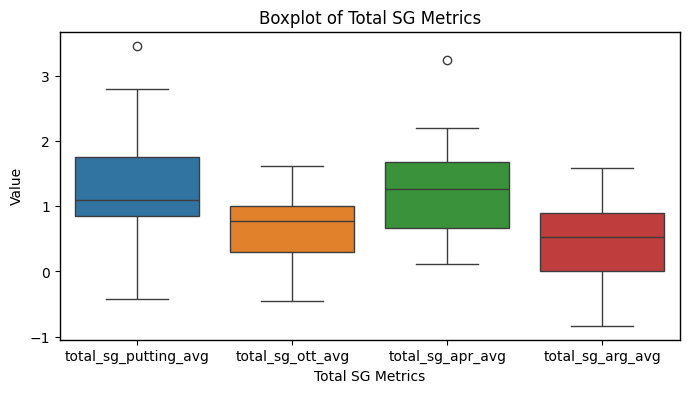

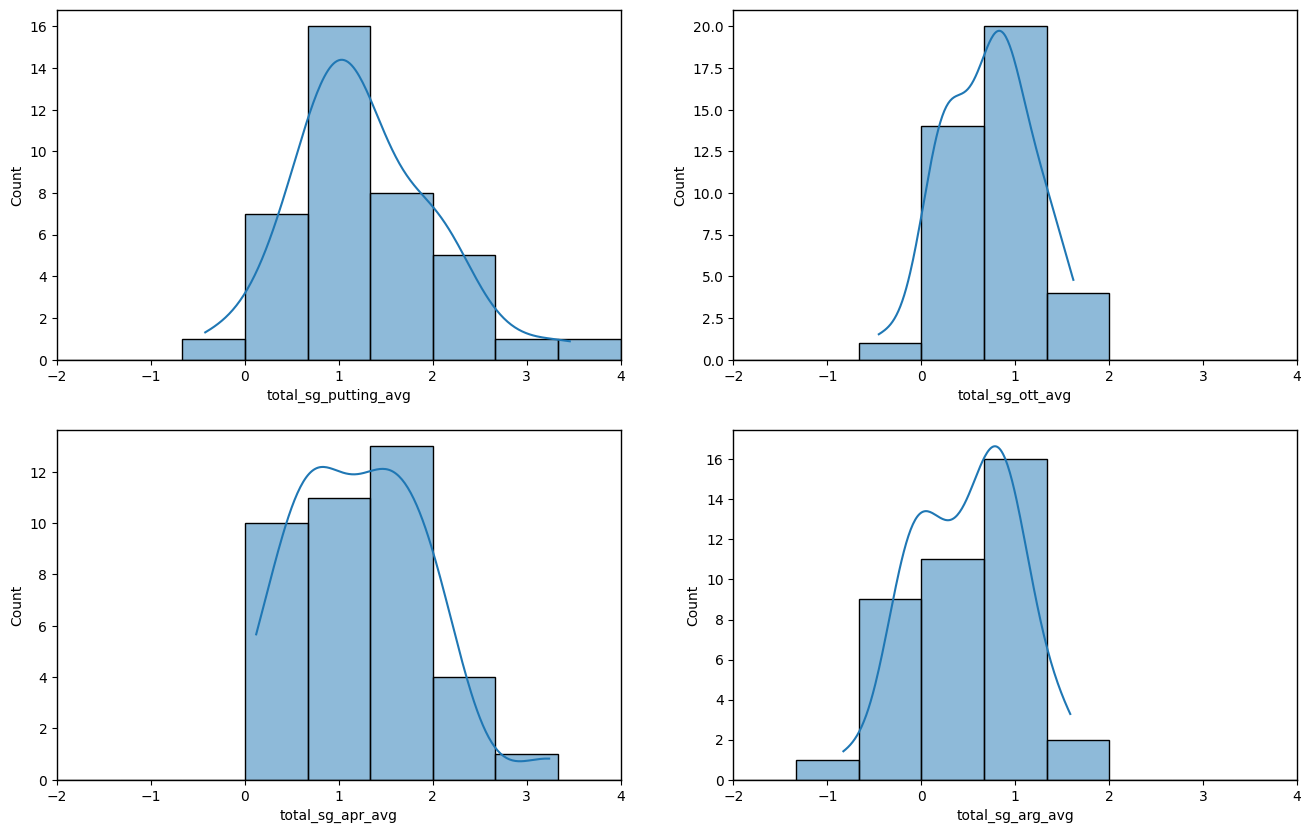

In [431]:
# create a boxplot for each total_sg metric
plt.figure(figsize=(8, 4))
sns.boxplot(data=combined_sg_putt_ttg[["total_sg_putting_avg", "total_sg_ott_avg", "total_sg_apr_avg", "total_sg_arg_avg"]])
plt.title("Boxplot of Total SG Metrics")
plt.xlabel("Total SG Metrics")
plt.ylabel("Value")
plt.show()

# create a histogram for each total_sg metric
plt.figure(figsize=(16, 10))
for col in ["total_sg_putting_avg", "total_sg_ott_avg", "total_sg_apr_avg", "total_sg_arg_avg"]:
    subplot = plt.subplot(2, 2, ["total_sg_putting_avg", "total_sg_ott_avg", "total_sg_apr_avg", "total_sg_arg_avg"].index(col) + 1)
    # make the x axis range the same for all histograms
    subplot.set_xlim(-2, 4)
    # make evenly spaced bins and use them for each histogram
    bins = np.linspace(-2, 4, 10)
    sns.histplot(data=combined_sg_putt_ttg[col], kde=True, bins=bins, label=col, ax=subplot)
plt.show()

### Final Attempt

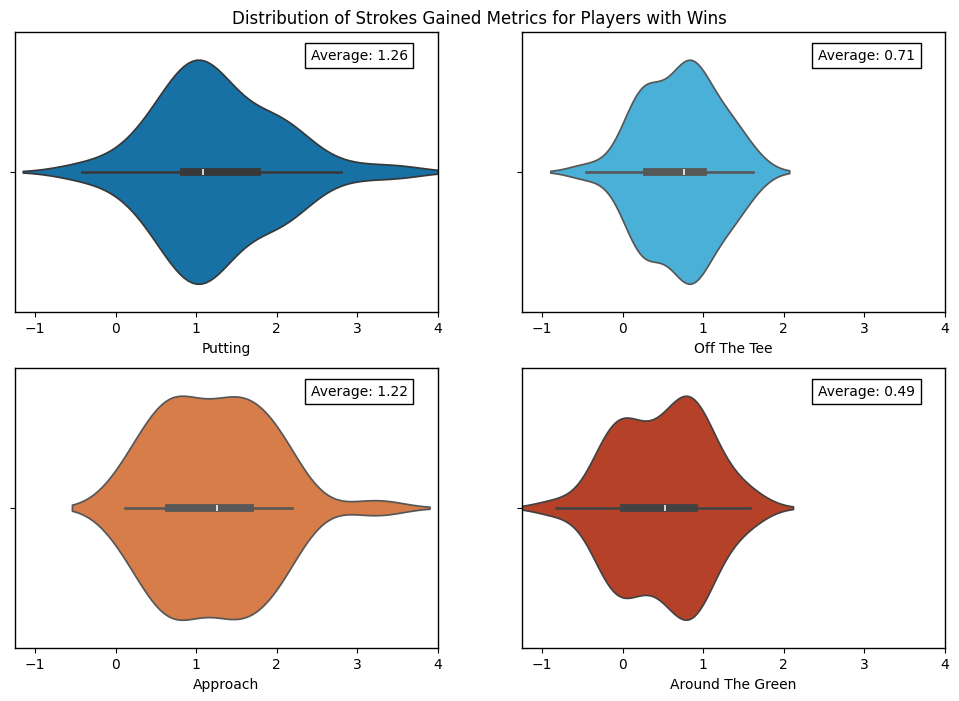

In [432]:
# create side by side violin plots for each total_sg metric, with the same x-axis
plt.figure(figsize=(12, 8))
plt.title("Distribution of Strokes Gained Metrics for Players with Wins", fontsize=12)
# hide x and y axis ticks
plt.xticks([])
plt.yticks([])
# remove the spines
spine_names = ('top','right', 'bottom', 'left')
for spine_name in spine_names:
    plt.gca().spines[spine_name].set_visible(False)
# set the colors for each violin plot
colors = ["#0077BB","#33BBEE","#EE7733","#CC3311"]
# set the x axis labels for each subplot
x_axis_labels = ["Putting", "Off The Tee", "Approach", "Around The Green"]
# create a subplot for each total_sg metric
for i, col in enumerate(["total_sg_putting_avg", "total_sg_ott_avg", "total_sg_apr_avg", "total_sg_arg_avg"]):
    subplot = plt.subplot(2, 2, i + 1)
    # set the x axis range the same for all violin plots
    subplot.set_xlim(-1.25, 4)
    # create each violin plot and color code each violin plot by the total_sg metric
    sns.violinplot(x=col, data=combined_sg_putt_ttg, ax=subplot, color=colors[i])
    # change x axis labels for each subplot
    subplot.set_xlabel(x_axis_labels[i])
    # add average in text box, in the top left corner of each subplot
    avg_value = combined_sg_putt_ttg[col].mean()
    # add the average value to the text box
    plt.text(0.70, .90, f"Average: {avg_value:.2f}", transform=plt.gca().transAxes, bbox=dict(facecolor='white', edgecolor='black'))


## Do the top 20 players (by season-long strokes gained total) exhibit different trends or consistency in their 3‑tournament rolling average strokes gained compared with the rest of the field?

### Data Analysis

In [ ]:
# loading the data
sg_total = pd.read_csv("./pga_tour_2024/pgatour_stats_02675(SG Total)_2024.csv")
results_2024 = pd.read_csv("2024_results.csv")

In [434]:
sg_total.head()

,rank,player,avg,total_sg_t,total_sg_t2g,total_sg_p,measured_rounds,tournament
0,1,Maverick McNealy,3.516,10.548,6.859,3.689,3,The RSM Classic
1,2,J.T. Poston,3.183,9.548,8.505,1.043,3,The RSM Classic
2,3,Mackenzie Hughes,3.172,9.517,2.934,6.583,3,The RSM Classic
3,4,Joel Dahmen,2.506,7.517,8.674,-1.157,3,The RSM Classic
4,4,Ben Griffin,2.506,7.517,5.013,2.504,3,The RSM Classic


In [435]:
results_2024.head()

,Tournament,Course,Date,POS,PLAYER,TOTAL,THRU,ROUND,R1,R2,R3,STROKES,R4,PROJ.,STARTING
0,Grant Thornton Invitational,Tiburón Golf Club,DEC 13 - 15,1,Tavatanakit / Knapp,-27,F,-7,58,66,65,189,NaN,NaN,NaN
1,Grant Thornton Invitational,Tiburón Golf Club,DEC 13 - 15,2,Thitikul / Kim,-26,F,-8,62,64,64,190,NaN,NaN,NaN
2,Grant Thornton Invitational,Tiburón Golf Club,DEC 13 - 15,3,Kupcho / Bhatia,-25,F,-8,59,68,64,191,NaN,NaN,NaN
3,Grant Thornton Invitational,Tiburón Golf Club,DEC 13 - 15,4,Henderson / Conners,-24,F,-10,59,71,62,192,NaN,NaN,NaN
4,Grant Thornton Invitational,Tiburón Golf Club,DEC 13 - 15,5,Boutier / Pavon,-21,F,-7,63,67,65,195,NaN,NaN,NaN


- For this visualization I will be using the following columns:
    - sg_total
        - avg - the average strokes gained for the player
        - total_sg_t - the total strokes gained for the tournament
        - measured_rounds - the number of rounds for the tournament
    - results_2024
        - player - the players name
        - tournament - the tournament name
        - end_date - the date range for the tournament


### Data Processing

In [436]:
# lowercase all columns in results_2024
results_2024.columns = results_2024.columns.str.lower()

# change date columns to datetime of last day
for index, row in results_2024.iterrows():
    # some dates have 4 parts
    if len(row["date"].split(" ")) > 4:
        results_2024.at[index, "end_date"] = pd.to_datetime(
            row["date"].split(" ")[0] + " " + row["date"].split(" ")[4] + " 2024",
            format="%b %d %Y",
        )
    else:
        results_2024.at[index, "end_date"] = pd.to_datetime(
            row["date"].split(" ")[0] + " " + row["date"].split(" ")[3] + " 2024",
            format="%b %d %Y",
        )

In [437]:
# join sg_total with results_2024 on player and tournament
season_sg_totals = sg_total.merge(results_2024, on=["player", "tournament"], how="left")
# keep only the columns we need: player, tournament, avg, end_date
season_sg_totals = season_sg_totals[["player", "tournament", "avg", "end_date", "total_sg_t", "measured_rounds"]]

# create top 10 players by avg sg total
# group by player and sum
top_10_players = season_sg_totals[["player", "total_sg_t", "measured_rounds"]].groupby("player").sum(numeric_only=True).reset_index()
# calculate the season average for each player
top_10_players['season_avg'] = top_10_players["total_sg_t"] / top_10_players["measured_rounds"]
# sort the players by season average and take the top 10
top_10_players = top_10_players.sort_values(by="season_avg", ascending=False).head(10)

# create top 20 players by avg sg total
# group by player and sum
top_20_players = season_sg_totals[["player", "total_sg_t", "measured_rounds"]].groupby("player").sum(numeric_only=True).reset_index()
# calculate the season average for each player
top_20_players['season_avg'] = top_20_players["total_sg_t"] / top_20_players["measured_rounds"]
# sort the players by season average and take the top 10
top_20_players = top_20_players.sort_values(by="season_avg", ascending=False).head(20)

# filter season_sg_totals for top 10 players, create a new dataframe
season_sg_totals_top10 = season_sg_totals.copy()
season_sg_totals_top10 = season_sg_totals_top10[season_sg_totals_top10["player"].isin(top_10_players["player"])]

# filter season_sg_totals for top 20 players
season_sg_totals_top20 = season_sg_totals.copy()
season_sg_totals_top20 = season_sg_totals_top20[season_sg_totals_top20["player"].isin(top_20_players["player"])]

# sort the top20 players by end_date
season_sg_totals_top20.sort_values(by=["end_date"], inplace=True)
# group by end_date and tournament and sum
season_sg_totals_top20_avg_by_end_date = season_sg_totals_top20.groupby(["end_date", "tournament"]).sum(numeric_only=True).reset_index()
# calculate the average strokes gained total for each end_date and tournament
season_sg_totals_top20_avg_by_end_date['avg'] = season_sg_totals_top20_avg_by_end_date["total_sg_t"] / season_sg_totals_top20_avg_by_end_date["measured_rounds"]
# calculate the rolling average of the average strokes gained total for each end_date and tournament
season_sg_totals_top20_avg_by_end_date['rolling5'] = season_sg_totals_top20_avg_by_end_date['avg'].rolling(window=3, min_periods=1).mean()
# change Myrtle Beach Classic to end_date to 2024-05-11, do this there is a duplicate end_date
season_sg_totals_top20_avg_by_end_date.loc[season_sg_totals_top20_avg_by_end_date['tournament'] == 'Myrtle Beach Classic', 'end_date'] = pd.to_datetime('2024-05-11')

# same method as top 20 but for all players
season_sg_totals_all = season_sg_totals.copy()

# remove top 20 players from season_sg_totals_all
season_sg_totals_all = season_sg_totals_all[~season_sg_totals_all["player"].isin(top_20_players["player"])]
# sort all players by end_date
season_sg_totals_all.sort_values(by=["end_date"], inplace=True)
# group by end_date and tournament and sum
season_sg_totals_all_avg_by_end_date = season_sg_totals_all.groupby(["end_date", "tournament"]).sum(numeric_only=True).reset_index()
# calculate the average strokes gained total for each end_date and tournament
season_sg_totals_all_avg_by_end_date['avg'] = season_sg_totals_all_avg_by_end_date["total_sg_t"] / season_sg_totals_all_avg_by_end_date["measured_rounds"]
# calculate the rolling average of the average strokes gained total for each end_date and tournament
season_sg_totals_all_avg_by_end_date['rolling5'] = season_sg_totals_all_avg_by_end_date['avg'].rolling(window=3, min_periods=1).mean()
# change Myrtle Beach Classic to end_date to 2024-05-11, do this there is a duplicate end_date
season_sg_totals_all_avg_by_end_date.loc[season_sg_totals_all_avg_by_end_date['tournament'] == 'Myrtle Beach Classic', 'end_date'] = pd.to_datetime('2024-05-11')

### Intial Analysis

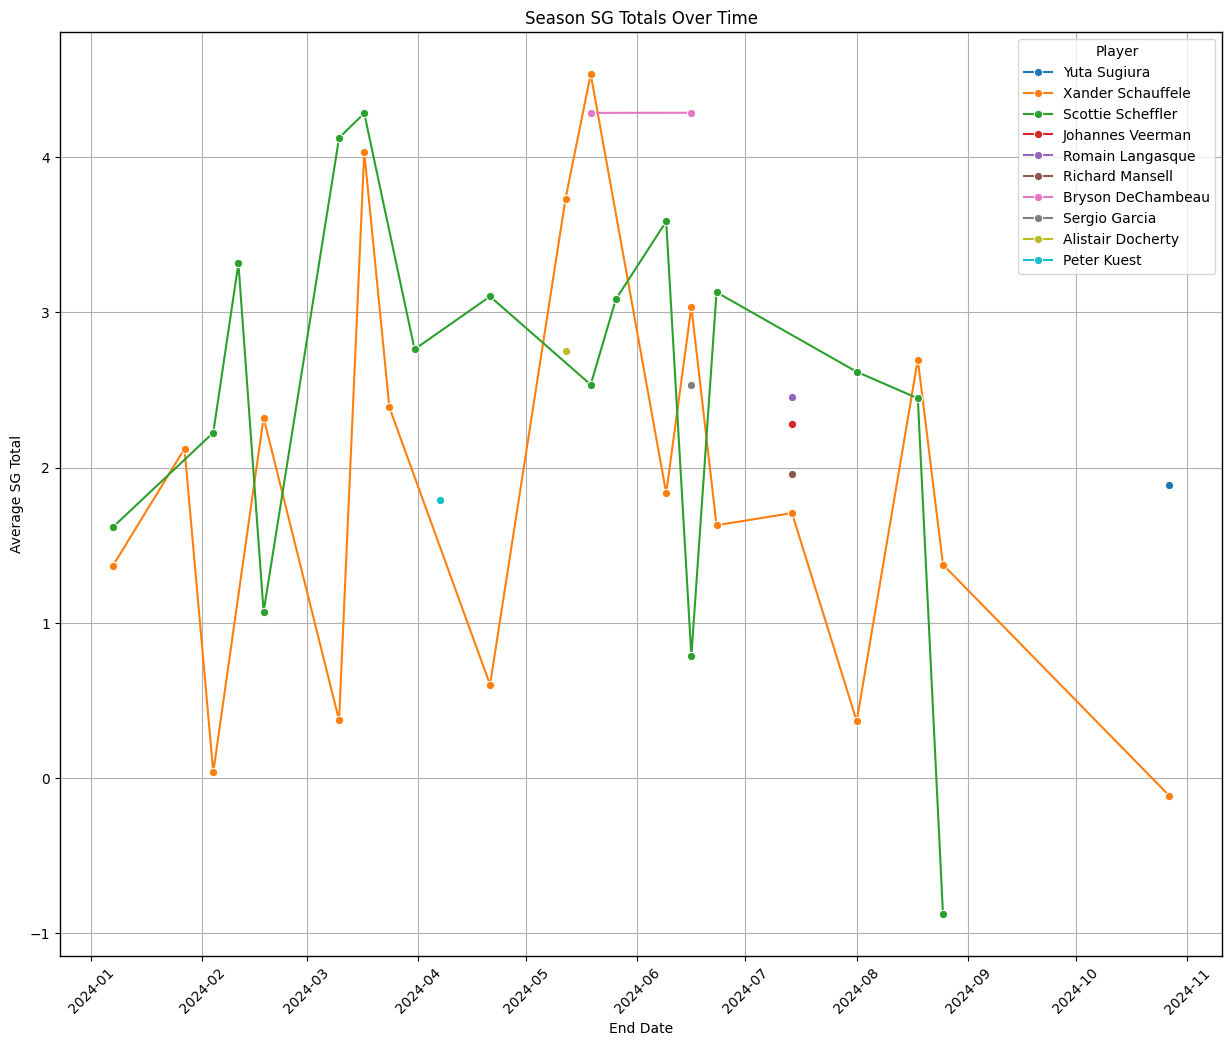

In [438]:
# create a time series plot of season_sg_totals
plt.figure(figsize=(15, 12))    
sns.lineplot(x="end_date", y="avg", hue="player", data=season_sg_totals_top10, marker='o')
plt.title("Season SG Totals Over Time")
plt.xlabel("End Date")
plt.ylabel("Average SG Total")
plt.xticks(rotation=45)
plt.grid()
plt.legend(title='Player')
plt.show()

### Final Attempt

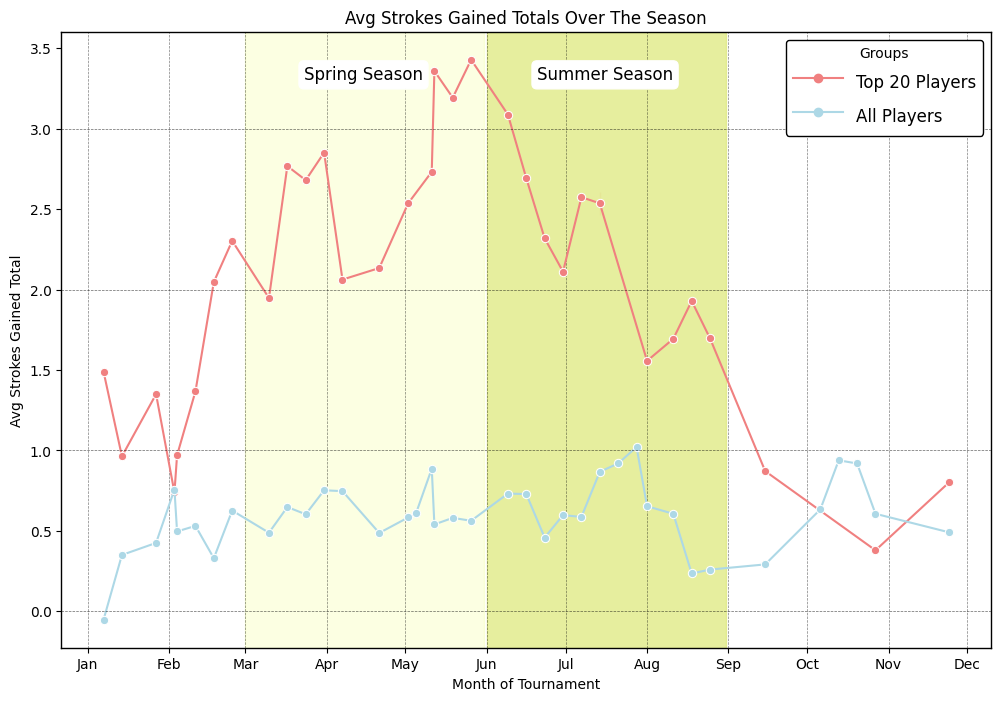

In [ ]:
# create a time series plot of season_sg_totals
plt.figure(figsize=(12, 8))    

# create a line plot fo the top 20 players and all players
sns.lineplot(x="end_date", y="rolling5", data=season_sg_totals_top20_avg_by_end_date, marker='o', color='lightcoral', label='Top 20 Players')
sns.lineplot(x="end_date", y="rolling5", data=season_sg_totals_all_avg_by_end_date, marker='o', color='lightblue', label='All Players')

# add title and labels
plt.title("Avg Strokes Gained Totals Over The Season")
plt.xlabel("Month of Tournament")
plt.ylabel("Avg Strokes Gained Total")

# change dates to month names
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))
# add hatch between march 1st and may 31st
plt.axvspan(pd.to_datetime("2024-03-01"), pd.to_datetime("2024-05-31"), color="#F1FF70", alpha=0.2, label='Spring Season')
# add hatch between june 1st and august 31st
plt.axvspan(pd.to_datetime("2024-06-01"), pd.to_datetime("2024-08-31"), color='#DCE775', alpha=0.7, label='Summer Season')

# add a legend  
handles = [
    plt.Line2D([0], [0], color='lightcoral', marker='o', linestyle='-'),
    plt.Line2D([0], [0], color='lightblue', marker='o', linestyle='-')
]
plt.legend(
    handles=handles,
    labels=['Top 20 Players', 'All Players'],
    title='Groups',
    handlelength=3,
    handleheight=2,
    loc='upper right',
    fontsize=12,
    facecolor='white',
    framealpha=1.0,
    edgecolor='black'
)

# put text box over the spring season, center in between mar 1 and may 31
mid   = dt.date(2024, 3, 1) + (dt.date(2024, 5, 31) - dt.date(2024, 3, 1))/2
trans = mtransforms.blended_transform_factory(plt.gca().transData, plt.gca().transAxes)
plt.text(mid, 0.93, "Spring Season",
        transform=trans,
        ha='center', va='center',
        fontsize=12,
        alpha=1,
        bbox=dict(facecolor='white', edgecolor='white', boxstyle='round,pad=0.3'))

# put text box over the summer season, center in between jun 1 and aug 31
mid   = dt.date(2024, 6, 1) + (dt.date(2024, 8, 31) - dt.date(2024, 6, 1))/2
trans = mtransforms.blended_transform_factory(plt.gca().transData, plt.gca().transAxes)
plt.text(mid, 0.93, "Summer Season",
        transform=trans,
        ha='center', va='center',
        fontsize=12,
        alpha=1,
        bbox=dict(facecolor='white', edgecolor='white', boxstyle='round,pad=0.3'))

# add horizontal lines at 0, 1, 2, and 3
plt.axhline(y=0, color=(0, 0, 0, 0.6), linestyle='--', linewidth=0.5)
plt.axhline(y=1, color=(0, 0, 0, 0.6), linestyle='--', linewidth=0.5)
plt.axhline(y=2, color=(0, 0, 0, 0.6), linestyle='--', linewidth=0.5)
plt.axhline(y=3, color=(0, 0, 0, 0.6), linestyle='--', linewidth=0.5)

# add vertical grid lines
plt.grid(axis='x', linestyle='--', color=(0, 0, 0, 0.6), linewidth=0.5, alpha=0.5)
plt.show()